# Датасет k_VV и регрессия по температуре

1. **Датасет** — длинный формат: `T`, `i1`, `f1`, `i2`, `f2`, `k_VV` (см³/с, как в `k_vv_mm`). Имя файла: `{particle1}_{particle2}_dataset.csv`.
2. **Регрессия** — модель в логарифме: $\ln k(T) = \sum_{j=0}^{n-1} a_j\, T^{-j/3}$; для каждого перехода подбирается степень полинома с минимальной MAPE. Результат: `{particle1}_{particle2}_regression_coefs.csv` со столбцами `i1`, `f1`, `i2`, `f2`, `a_0`, …, `a_{n-1}`.
3. **График** — сравнение «точного» `k_vv_mm` и значения по регрессии для выбранного перехода.

**Замечание.** Для регрессии нужна **сетка температур** (не одна точка). Ниже по умолчанию диапазон начинается с 300 K; при необходимости оставьте только `np.array([300.0])` для выгрузки датасета без подгонки.

Тетрадку следует запускать с рабочей папкой `FHO_FR_VV` (импорты `particles`, `k_vv_mm`).

In [6]:
from __future__ import annotations

import multiprocessing as mp
import os
import sys
import time
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from particles import N2, O2
from k_VV import k_vv_mm
from tqdm import tqdm

## Параметры

In [7]:
# --- Частицы ---
M1, M2 = O2, O2

# Максимальные колебательные уровни 0 … V_MAX включительно
V_MAX = 5

# Сетка температур для датасета и регрессии [K]
TEMPERATURES_K = np.concatenate([np.linspace(300.0, 1000.0, 3), np.linspace(2000.0, 6000.0, 4)])

# Файлы (имена строятся автоматически из M1.name, M2.name)
WORKDIR = Path(".")
PARTICLE_PAIR = f"{M1.name}_{M2.name}"
DATASET_PATH = WORKDIR / f"{PARTICLE_PAIR}_dataset_new.csv"
COEFS_PATH = WORKDIR / f"{PARTICLE_PAIR}_regression_coefs_new.csv"

## Генерация датасета

In [8]:
# --- Конфигурация переходов ---
WORKERS = os.cpu_count()


def generate_transitions(v_max: int) -> set[tuple[int, int, int, int]]:
    """Перебор по квантовым числам v, w; переходы задаются явно."""
    out = set()
    for v in range(v_max + 1):
        for w in range(v_max + 1):
            # Обе молекулы возбуждаются: v→v+1, w+1→w
            if v + 1 <= v_max and w + 1 <= v_max:
                i1, f1, i2, f2 = w, w + 1, v + 1, v
                # if i1 > i2:
                out.add((i1, f1, i2, f2))
            # Обе молекулы де-возбуждаются: v→v-1, w-1→w
            if v - 1 >= 0 and w - 1 >= 0:
                i1, f1, i2, f2 = w, w - 1, v - 1, v
                # if i1 > i2:
                out.add((i1, f1, i2, f2))
            # Мол.2 возбуждается, мол.1 де-возбуждается: v→v-1, w→w+1
            if v - 1 >= 0 and w + 1 <= v_max:
                i1, f1, i2, f2 = w, w + 1, v, v - 1
                # if i1 > i2:
                out.add((i1, f1, i2, f2))
            # Мол.2 де-возбуждается, мол.1 возбуждается: v→v+1, w→w-1
            if v + 1 <= v_max and w - 1 >= 0:
                i1, f1, i2, f2 = w, w - 1, v, v + 1
                # if i1 > i2:
                out.add((i1, f1, i2, f2))
    return out


# --- Генерация (параллельная) ---
_M1_WORKER = None
_M2_WORKER = None


def _worker_init(m1, m2) -> None:
    global _M1_WORKER, _M2_WORKER
    _M1_WORKER, _M2_WORKER = m1, m2


def _compute_row(task: tuple[int, int, int, int, float]) -> dict:
    i1, f1, i2, f2, Tf = task
    from k_VV import k_vv_mm

    k = float(k_vv_mm(_M1_WORKER, _M2_WORKER, i1, f1, i2, f2, Tf))
    return {"T": float(Tf), "i1": i1, "f1": f1, "i2": i2, "f2": f2, "k_VV": k}


transitions = sorted(generate_transitions(V_MAX))
tasks = [
    (i1, f1, i2, f2, float(T))
    for T in TEMPERATURES_K
    for i1, f1, i2, f2 in transitions
]

t0 = time.time()
rows: list[dict] = []
exec_kw = {"initializer": _worker_init, "initargs": (M1, M2)}
if sys.platform != "win32":
    exec_kw["mp_context"] = mp.get_context("fork")

with ProcessPoolExecutor(max_workers=WORKERS, **exec_kw) as ex:
    for row in tqdm(ex.map(_compute_row, tasks), total=len(tasks), desc="k_VV"):
        rows.append(row)

df_dataset = pd.DataFrame(rows)
df_dataset = df_dataset.sort_values(
    ["T", "i1", "f1", "i2", "f2"], kind="mergesort"
).reset_index(drop=True)
elapsed = time.time() - t0
print(
    f"Переходов: {len(transitions)}, строк: {len(df_dataset)}, "
    f"время: {elapsed:.2f} s, workers={WORKERS}"
)
df_dataset.to_csv(DATASET_PATH, index=False)
print(f"Сохранено: {DATASET_PATH.resolve()}")
df_dataset.head()

k_VV: 100%|██████████| 350/350 [2:26:27<00:00, 25.11s/it]  


Переходов: 50, строк: 350, время: 8787.75 s, workers=18
Сохранено: /Users/andrey/projects/fho_gen/FHO_FR_VV/O2_O2_dataset_new.csv


,T,i1,f1,i2,f2,k_VV
0,300.0,0,1,1,0,2.357125e-14
1,300.0,0,1,2,1,4.628915e-14
2,300.0,0,1,3,2,6.404511e-14
3,300.0,0,1,4,3,7.462001e-14
4,300.0,0,1,5,4,7.798030e-14


## Регрессия

In [6]:
POLY_TERM_COUNTS = range(2, 3)


def mape_loss(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100.0)


def k_model_poly(T, *coeffs):
    x = T ** (-1 / 3)
    return sum(c * x**k for k, c in enumerate(coeffs))


def k_predict_from_ln_poly(T_arr: np.ndarray, coeffs: np.ndarray) -> np.ndarray:
    T_arr = np.asarray(T_arr, dtype=float)
    return np.exp(k_model_poly(T_arr, *coeffs))


def fit_all_transitions(
    df: pd.DataFrame, poly_term_counts=POLY_TERM_COUNTS
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    df — длинный формат.
    Возвращает таблицу коэффициентов и wide-таблицу предсказанных k для MAPE-проверки.
    """
    df["transition"] = list(zip(df["i1"], df["f1"], df["i2"], df["f2"]))
    wide = df.pivot(index="T", columns="transition", values="k_VV")

    coeffs_rows = []
    pred_wide = pd.DataFrame(index=wide.index)

    T_col = wide.index.astype(float).values

    for col in wide.columns:
        y = wide[col].values.astype(float)

        best_mape = np.inf
        best_coeffs = None

        y_log = np.log(y)
        norm_factor = np.abs(y_log).max()
        y_norm = y_log / norm_factor

        for nc in poly_term_counts:
            params_norm, _ = curve_fit(
                k_model_poly,
                T_col,
                y_norm,
                p0=np.ones(nc),
                method="lm",
            )
            coeffs = params_norm * norm_factor
            k_pred = np.exp(k_model_poly(T_col, *coeffs))
            mm = mape_loss(y, k_pred)
            if mm < best_mape:
                best_mape = mm
                best_coeffs = coeffs

        assert best_coeffs is not None
        i1, f1, i2, f2 = col
        coeffs_rows.append(
            {"i1": i1, "f1": f1, "i2": i2, "f2": f2, "_mape": best_mape, "coeffs": best_coeffs}
        )
        pred_wide[col] = k_predict_from_ln_poly(T_col, best_coeffs)

    coeff_len = max(len(r["coeffs"]) for r in coeffs_rows)
    out = pd.DataFrame(
        [
            {
                "i1": r["i1"],
                "f1": r["f1"],
                "i2": r["i2"],
                "f2": r["f2"],
                **{f"a_{j}": r["coeffs"][j] if j < len(r["coeffs"]) else np.nan for j in range(coeff_len)},
            }
            for r in coeffs_rows
        ]
    )
    out.insert(5, "mape_pct", [r["_mape"] for r in coeffs_rows])
    return out, pred_wide


# --- Запуск регрессии ---
df_long = pd.read_csv(DATASET_PATH)
df_long["T"] = df_long["T"].astype(float)
df_long["i1"] = df_long["i1"].astype(int)
df_long["f1"] = df_long["f1"].astype(int)
df_long["i2"] = df_long["i2"].astype(int)
df_long["f2"] = df_long["f2"].astype(int)
df_long["k_VV"] = df_long["k_VV"].astype(float)

df_coeffs, df_pred_wide = fit_all_transitions(df_long.copy())
df_coeffs.drop(columns=["mape_pct"]).to_csv(COEFS_PATH, index=False)
print(f"Сохранено: {COEFS_PATH.resolve()}")
df_coeffs.head()

Сохранено: /Users/andrey/projects/fho_gen/FHO_FR_VV/N2_N2_regression_coefs_new.csv


,i1,f1,i2,f2,a_0,mape_pct,a_1
0,1,0,0,1,-26.750791,6.104573,-35.188823
1,2,1,0,1,-26.011309,5.941479,-35.696504
2,2,1,1,2,-25.347742,6.060821,-35.137549
3,2,3,1,0,-25.490964,5.531947,-37.184390
4,3,2,0,1,-25.490964,5.531947,-37.184390


In [ ]:
df_coeffs_with_mape = df_coeffs.copy()
df_coeffs_with_mape.to_csv(
    WORKDIR / f"{PARTICLE_PAIR}_regression_coefs_with_mape.csv",
    index=False,
)

## График: точный k_VV и регрессия для выбранного перехода

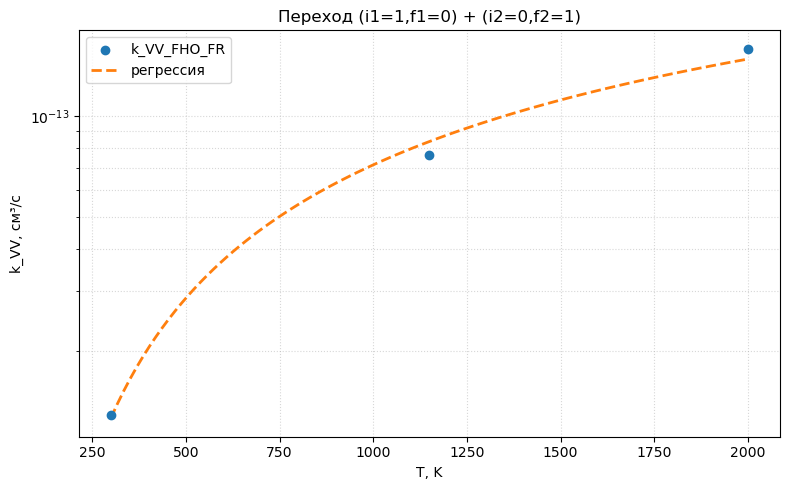

In [9]:
PLOT_TRANSITION = (1, 0, 0, 1)


def row_coeffs_for_transition(
    df_coef: pd.DataFrame, i1: int, f1: int, i2: int, f2: int
) -> np.ndarray:
    mask = (
        (df_coef["i1"] == i1)
        & (df_coef["f1"] == f1)
        & (df_coef["i2"] == i2)
        & (df_coef["f2"] == f2)
    )
    if not mask.any():
        raise KeyError((i1, f1, i2, f2))
    row = df_coef.loc[mask].iloc[0]
    a_cols = [c for c in df_coef.columns if c.startswith("a_")]
    vals = [row[c] for c in sorted(a_cols, key=lambda s: int(s.split("_")[1]))]
    return np.array([v for v in vals if pd.notna(v)], dtype=float)


i1_p, f1_p, i2_p, f2_p = PLOT_TRANSITION

# Точные точки из датасета
msk = (
    (df_dataset["i1"] == i1_p)
    & (df_dataset["f1"] == f1_p)
    & (df_dataset["i2"] == i2_p)
    & (df_dataset["f2"] == f2_p)
)
dsub = df_dataset.loc[msk].sort_values("T")

# Регрессионная кривая из коэффициентов
cfs = row_coeffs_for_transition(df_coeffs, i1_p, f1_p, i2_p, f2_p)
T_fine = np.linspace(TEMPERATURES_K.min(), TEMPERATURES_K.max(), 100)
k_reg_fine = k_predict_from_ln_poly(T_fine, cfs)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(dsub["T"], dsub["k_VV"], color="C0", s=36, label="k_VV_FHO_FR", zorder=3)
ax.plot(T_fine, k_reg_fine, "--", color="C1", lw=2, label="регрессия")
ax.set_xlabel("T, K")
ax.set_ylabel("k_VV, см³/с")
ax.set_title(f"Переход (i1={i1_p},f1={f1_p}) + (i2={i2_p},f2={f2_p})")
ax.set_yscale("log")
ax.legend()
ax.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()